In [40]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

def compute_ds(ds):
    ds['S'] = ds.a+ds.b+ds.c
    ds['X_ab'] = -2*ds.a*ds.b
    ds['X_bc'] = -2*ds.b*ds.c
    ds['X_ac'] = -2*ds.a*ds.c
    ds['B_a'] = - ds.a*ds.b -ds.a*ds.c
    ds['B_b'] = - ds.a*ds.b -ds.b*ds.c
    ds['B_c'] = - ds.a*ds.c -ds.b*ds.c
    ds['E_a'] = ds.a*ds.S
    ds['E_b'] = ds.b*ds.S
    ds['E_c'] = ds.c*ds.S

def compute_ds_var(ds):
    ds['S'] = ds.a+ds.b+ds.c
    ds['X_ab'] = -2*(ds.a*ds.b - ds.a.mean()*ds.b.mean())
    ds['X_bc'] = -2*(ds.b*ds.c - ds.b.mean()*ds.c.mean())
    ds['X_ac'] = -2*(ds.a*ds.c - ds.a.mean()*ds.c.mean())
    ds['B_a'] = - ds.a*ds.b -ds.a*ds.c
    ds['B_b'] = - ds.a*ds.b -ds.b*ds.c
    ds['B_c'] = - ds.a*ds.c -ds.b*ds.c
    ds['E_a'] = ds.a*ds.S
    ds['E_b'] = ds.b*ds.S
    ds['E_c'] = ds.c*ds.S

def plot(ds, dsm):
    fig, axs = plt.subplots(1, 3, figsize = (10, 5), sharey=True)
    i=0
    for v in ['a','b','c']:
        ds[v].plot(ax=axs[i], c=c0[v])
        axs[i].grid()
        i+=1

    fig, ax = plt.subplots(1, 1, figsize = (10, 5))
    i = 0
    for v in ['a','b','c']:
        ax.bar(i, dsm[v], color= c0[v])
        ax.bar(i, dsm['B_'+v], width = 0.2, color= c0[v], edgecolor='k')
        ax.bar(i, dsm['E_'+v], width = 0.2, color= 'grey')
        i+=1
    for v in ['ab', 'ac', 'bc'] :
        ax.bar(i, dsm['X_' + v], color= c0[v])
        i+=1 
    ax.grid()

c0 = dict(a='b', b='r', c='y', ab='purple', ac = 'green', bc = 'orange')

# First case : 2 terms compensate c, no mean

$$a + b + c = 0$$

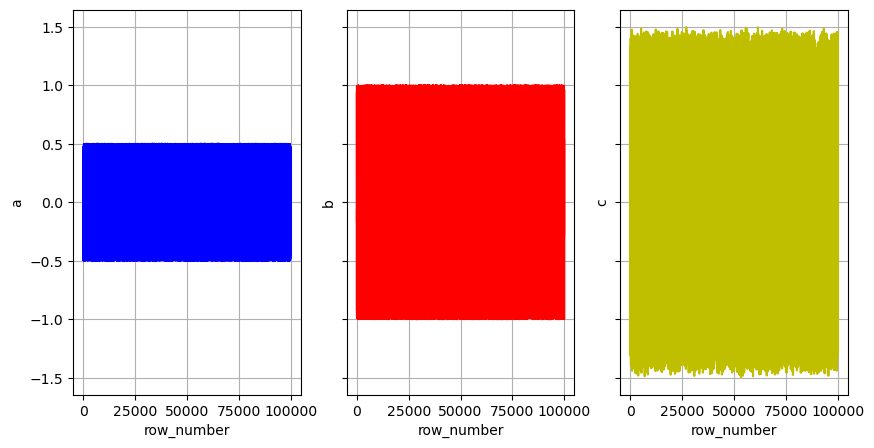

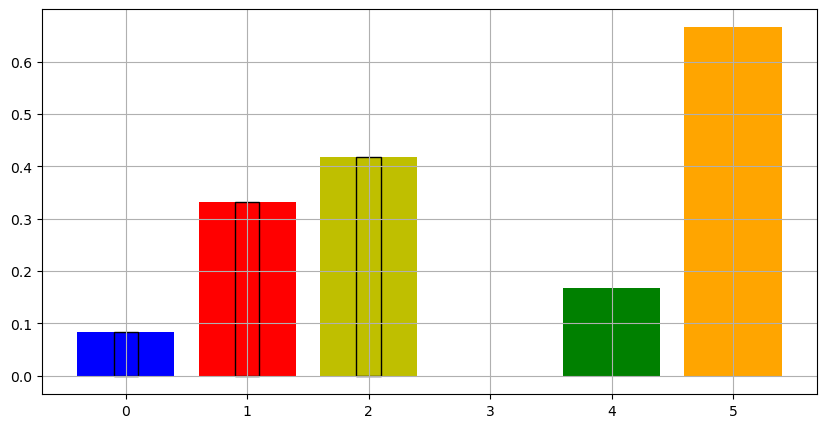

In [41]:
N = 100000
s0 = (np.random.rand(N)-0.5)*1
s1 = (np.random.rand(N)-0.5)*2
a = s0
b = s1
c = -s0 - s1

ds = xr.Dataset(data_vars=dict(a=('row_number', a),b=('row_number', b),c=('row_number', c),), 
                coords=dict(row_number = ('row_number', np.arange(N))),
               )
compute_ds(ds)
dsm = xr.merge([(ds[['a', 'b', 'c', 'S']]**2).mean(), ds[[v for v in ds if '_' in v]].mean()])
plot(ds, dsm)

# Second case : 2 terms compensate c, non null mean

- contribution negative de a et b, qui compensent ensemble c mais qui ne sont pas corrélés (X_ab = -2*(a.mean()x b.mean()))

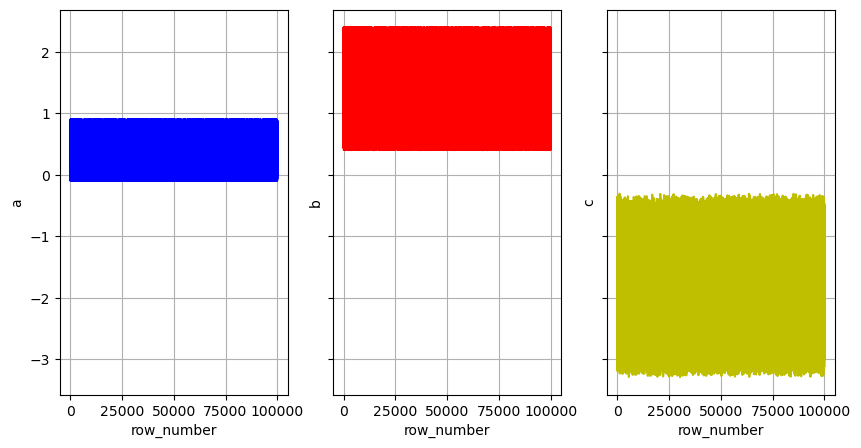

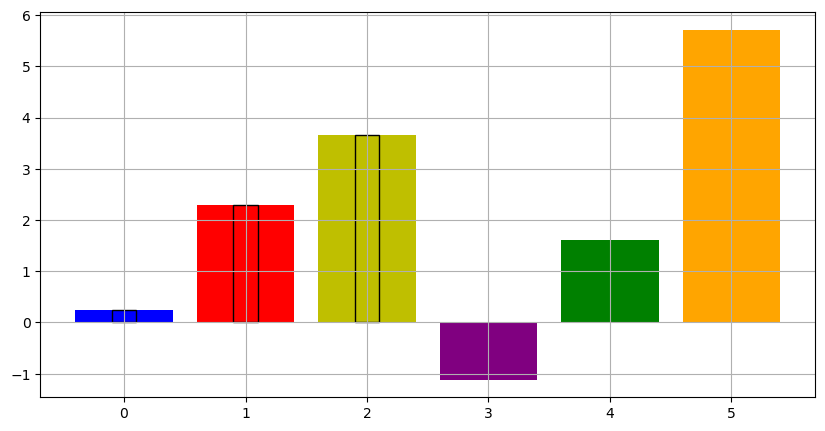

In [43]:
N = 100000
s0 = (np.random.rand(N)-0.1)*1
s1 = (np.random.rand(N)+0.2)*2
a = s0
b = s1
c = -s0 - s1

ds = xr.Dataset(data_vars=dict(a=('row_number', a),b=('row_number', b),c=('row_number', c),), 
                coords=dict(row_number = ('row_number', np.arange(N))),
               )
compute_ds(ds)
dsm = xr.merge([(ds[['a', 'b', 'c', 'S']]**2).mean(), ds[[v for v in ds if '_' in v]].mean()])
plot(ds, dsm)

In [23]:
ds.a.mean(), ds.b.mean(), (ds.a*ds.b).mean(), ds.a.mean()*ds.b.mean()

(<xarray.DataArray 'a' ()> Size: 8B
 array(0.40010464),
 <xarray.DataArray 'b' ()> Size: 8B
 array(1.39800609),
 <xarray.DataArray ()> Size: 8B
 array(0.55900841),
 <xarray.DataArray ()> Size: 8B
 array(0.55934872))

# Third case : 3 terms correlated, 0 means

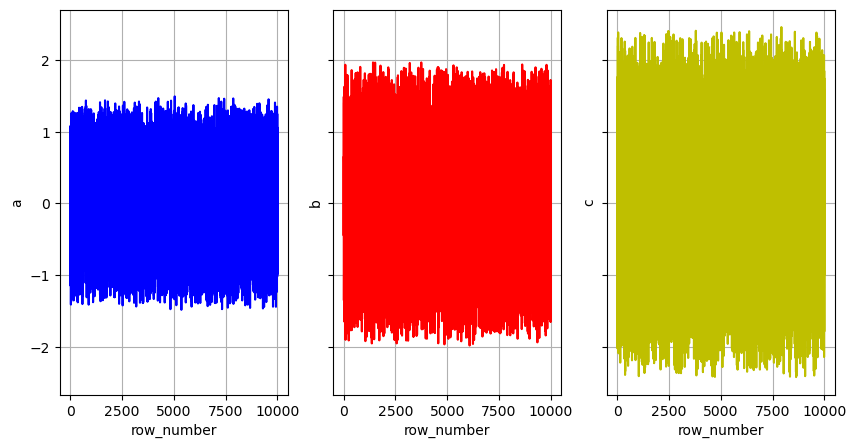

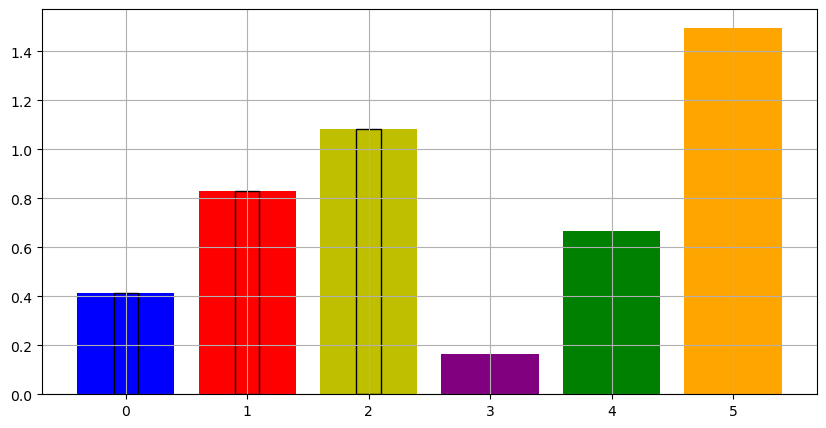

In [61]:
N = 10000
s0 = (np.random.rand(N)-0.5)*2
s1 = (np.random.rand(N)-0.5)*3
s2 = (np.random.rand(N)-0.5)*1
a = s0 + s2
b = s1 - s2
c = -s0 - s1 

ds = xr.Dataset(data_vars=dict(a=('row_number', a),b=('row_number', b),c=('row_number', c),), 
                coords=dict(row_number = ('row_number', np.arange(N))),
               )
compute_ds(ds)
dsm = xr.merge([(ds[['a', 'b', 'c', 'S']]**2).mean(), ds[[v for v in ds if '_' in v]].mean()])
    
plot(ds, dsm)    

# Fourth case : 3 terms correlated, non null means

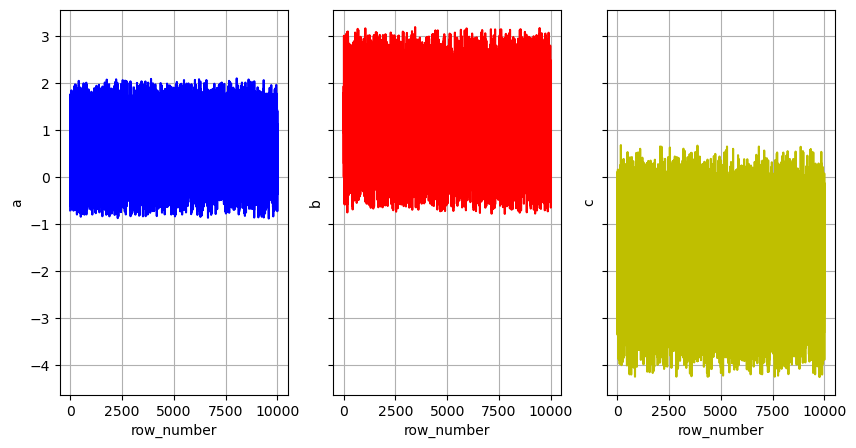

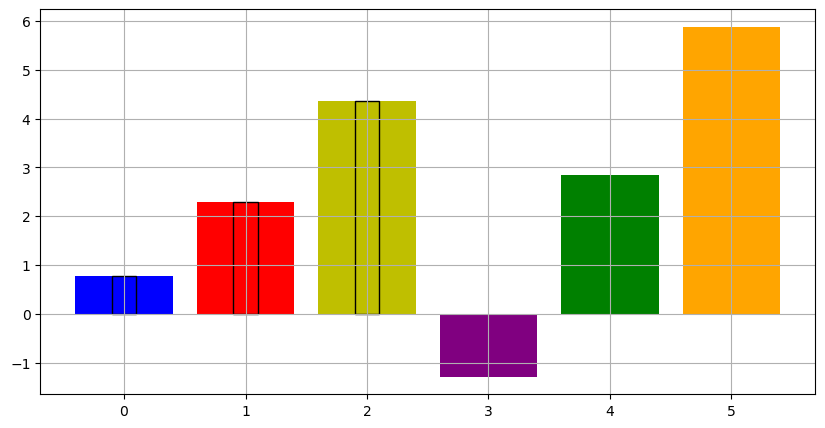

In [45]:
N = 10000
s0 = (np.random.rand(N)-0.2)*2
s1 = (np.random.rand(N)-0.1)*3
s2 = (np.random.rand(N)-0.5)*1
a = s0 + s2
b = s1 - s2
c = -s0 - s1 

ds = xr.Dataset(data_vars=dict(a=('row_number', a),b=('row_number', b),c=('row_number', c),), 
                coords=dict(row_number = ('row_number', np.arange(N))),
               )
compute_ds(ds)
dsm = xr.merge([(ds[['a', 'b', 'c', 'S']]**2).mean(), ds[[v for v in ds if '_' in v]].mean()])
    
plot(ds, dsm)    

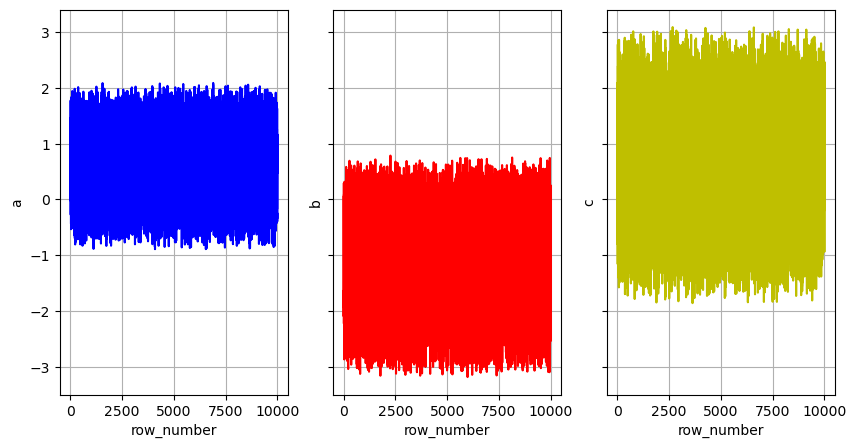

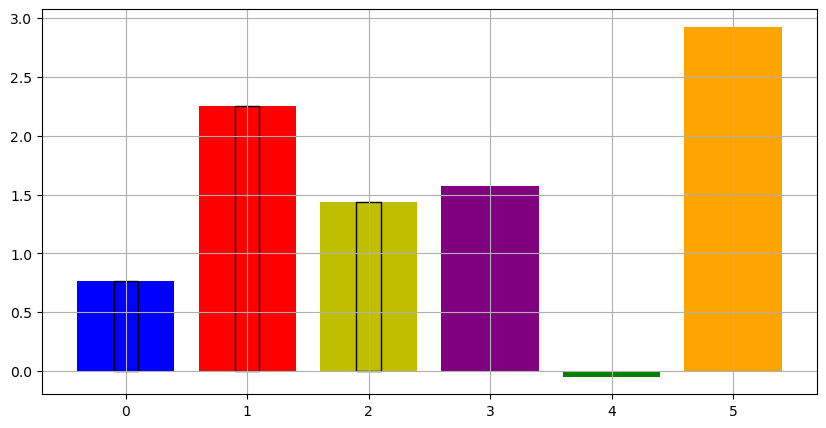

In [62]:
N = 10000
s0 = (np.random.rand(N)-0.2)*2# entre a et c
s1 = -(np.random.rand(N)-0.1)*3 #entre b et c
s2 = (np.random.rand(N)-0.5)*1 # entre a et b
a = s0 + s2
b = s1 - s2
c = -s0 - s1 

ds = xr.Dataset(data_vars=dict(a=('row_number', a),b=('row_number', b),c=('row_number', c),), 
                coords=dict(row_number = ('row_number', np.arange(N))),
               )
compute_ds(ds)
dsm = xr.merge([(ds[['a', 'b', 'c', 'S']]**2).mean(), ds[[v for v in ds if '_' in v]].mean()])
    
plot(ds, dsm)    

In [63]:
dsm.X_ab - ds

<xarray.DataArray 'X_ab' ()> Size: 8B
array(1.57759017)

In [60]:
-2*(-s2**2).mean()

np.float64(0.16533931921908415)

In [32]:
ds.a.mean()+ ds.b.mean() + ds.c.mean()

<xarray.DataArray ()> Size: 8B
array(-7.32747196e-15)

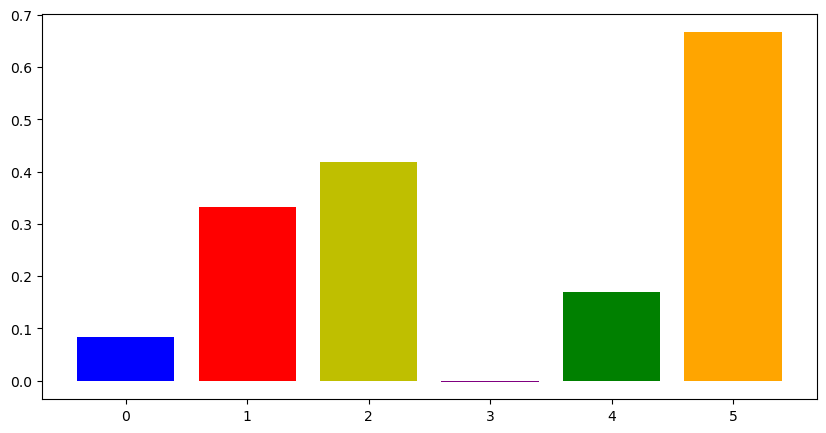

In [13]:
def plot(ds):
    fig, ax = plt.subplots(1, 1, figsize = (10, 5))
    i = 0
    for v in ['a','b','c']:
        ax.bar(i, ds[v], color= c0[v])
        ax.bar(i, ds['B_'+v], width = 0.2, color= c0[v])
        ax.bar(i, ds['E_'+v], width = 0.2, color= 'grey')
        i+=1
    for v in ['ab', 'ac', 'bc'] :
        ax.bar(i, ds['X_' + v], color= c0[v])
        i+=1
plot(dsm)
        
        

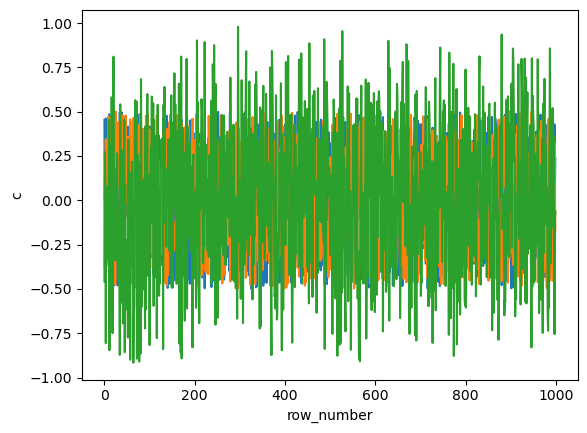

In [9]:
ds.a.plot()
ds.b.plot()
ds.c.plot()